# ANI · Asistente Normativo Institucional — versión final
**Liceo Polivalente Guillermo Labarca Hubertson** · ISY0101 Ingeniería de Soluciones con IA (DUOC UC) · Felipe y Adolfo

Agente con **LLM + RAG** que responde dudas de apoderados sobre el *Reglamento de Evaluación y Promoción 2026*, el *Reglamento Interno de Convivencia Escolar 2026* y el *Decreto 67/2018*, citando documento, ubicación y página.

### Antes de ejecutar
1. **GPU:** *Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU → Guardar* (sin GPU funciona, pero cada respuesta tarda mucho más).
2. **Clave de Gemini:** ícono 🔑 (barra izquierda) → *Secretos* → `GEMINI_API_KEY` con *Acceso al notebook* activado.
3. **Carpeta `ANI` en Drive** con: `Reglamento_Evaluacion_2026.pdf`, `Reglamento_Convivencia.pdf`, `Decreto_67_2018.pdf`, `logo_liceo.png`, `logo_slep.png`, `ANI_preguntas_hipoteticas.json` y `ANI_set_preguntas_prueba.xlsx`.
4. *Entorno de ejecución → Ejecutar todas.* La celda 7 entrega el link de la interfaz.

### Arquitectura
| Componente | Implementación |
|---|---|
| Fragmentación | PyMuPDF por sección / artículo / punto / protocolo → fragmentos de 800 caracteres con solape de 150 (divisor recursivo), cada uno con su **página exacta** (página impresa del reglamento) |
| Preguntas hipotéticas | *doc2query*: 3 preguntas tipo apoderado por fragmento, generadas una vez con Gemini y guardadas en Drive |
| Recuperación | Multi-consulta (consulta del agente + pregunta original) · híbrida: semántica (e5-small + ChromaDB), léxica (BM25) y preguntas hipotéticas, con fusión RRF · reranker cross-encoder multilingüe · anti-duplicados · contexto ampliado a la sección (padre-hijo) |
| Agente | Gemini con *function calling*: 4 herramientas (norma interna, Decreto 67, asistencia, plazos hábiles), memoria por conversación y respaldo de modelos |
| Controles | búsqueda obligatoria · re-búsqueda antes de rechazar · ocultamiento de RUT/correo/teléfono · trazabilidad |
| Interfaz | Gradio con colores y logos del liceo, fuentes desplegables y 👍/👎 con comentario (mejora continua revisada por UTP) |

### Resultados (evaluación IL1.4, 40 preguntas)
| Métrica | v1 | v3 | v5 | v6 |
|---|---|---|---|---|
| Exactitud vs referencia | 65,0 % | 90,0 % | 87,5 % | **92,5 %** |
| Context Recall | 62,5 % | 87,5 % | 84,4 % | **93,8 %** |
| Hit@k página esperada | 75,0 % | 84,4 % | 87,5 % | **96,9 %** |
| Rechazo correcto | 100 % | 100 % | 100 % | 100 % |

> El historial completo de iteraciones (v1 → v6), con el diagnóstico y la justificación de cada cambio, está en los notebooks P1–P4 del repositorio.


## 1 · Configuración

In [2]:
# ============================================================
# 1 · CONFIGURACIÓN: librerías, Drive, GPU y Gemini
# ============================================================
!pip install -q -U pymupdf chromadb sentence-transformers rank_bm25 holidays openpyxl gradio google-genai langchain-text-splitters

import os, re, json, glob, time, csv, html, base64, unicodedata
import datetime as dt
from zoneinfo import ZoneInfo
import torch
from google.colab import drive, userdata
from google import genai
from google.genai import types

# ---------- Archivos: carpeta ANI en Drive o, si no existe, la del repositorio de GitHub ----------
REPO_GITHUB = "https://github.com/felipits/ANI-asistente-normativo"
try:
    drive.mount("/content/drive")
    carpetas = [c for c in glob.glob("/content/drive/MyDrive/**/ANI", recursive=True)
                if os.path.exists(os.path.join(c, "Decreto_67_2018.pdf"))]
except Exception:
    carpetas = []
if not carpetas:
    print("No hay carpeta ANI en Drive: se descargan los archivos desde GitHub.")
    if not os.path.exists("/content/ANI_repo"):
        os.system(f"git clone -q {REPO_GITHUB} /content/ANI_repo")
    carpetas = ["/content/ANI_repo/ANI"]
CARPETA = carpetas[0]
print("📁 Carpeta:", CARPETA)

# ---------- GPU (el reranker es ~50 veces más rápido con GPU) ----------
DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
print("⚡ GPU activa" if DISPOSITIVO == "cuda" else
      "⚠️ Sin GPU: ANI funcionará, pero lento. Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU")

# ---------- Gemini (la clave va en 🔑 Secretos como GEMINI_API_KEY, nunca en el código) ----------
client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))
MODELOS = ["gemini-3.1-flash-lite", "gemini-flash-latest", "gemini-3.5-flash"]   # el más rápido primero; los otros, de respaldo
HOY = dt.datetime.now(ZoneInfo("America/Santiago")).date().isoformat()
PROBAR = False   # True para ver pruebas que gastan cuota de Gemini
EVALUAR = False  # True para volver a medir (celdas 9 y 10: ~30 min y gasta cuota de Gemini)
print("📅 Fecha (hora de Chile):", HOY)


Mounted at /content/drive
📁 Carpeta: /content/drive/MyDrive/6TO SEMESTRE (CS. DATOS)/Ingenieria de Soluciones con IA/ANI
⚡ GPU activa
📅 Fecha (hora de Chile): 2026-10-06


## 2 · Documentos → fragmentos citables

In [3]:
# ============================================================
# 2 · DOCUMENTOS → FRAGMENTOS CITABLES
#   Cada fragmento guarda documento, ubicación (sección / artículo / punto / protocolo) y páginas,
#   para que ANI pueda citar de dónde sale cada dato. Fragmentos de 800 caracteres con 150 de solape,
#   cada uno con su página exacta (mapa línea → página).
# ============================================================
import pymupdf


DOCUMENTOS = [
    # archivo, nombre para citar, tipo (interna/externa), año, páginas de portada/índice que se saltan
    ("Reglamento_Evaluacion_2026.pdf", "Reglamento de Evaluación y Promoción 2026", "interna", 2026, 3),
    ("Reglamento_Convivencia.pdf",     "Reglamento Interno de Convivencia Escolar 2026", "interna", 2026, 3),
    ("Decreto_67_2018.pdf",            "Decreto 67/2018 (MINEDUC)", "externa", 2018, 0),
]

# Los reglamentos numeran sus páginas sin contar la portada: la página impresa es la del PDF menos 1.
# ANI cita la página impresa, que es la que el apoderado ve escrita en el documento.
DESFASE_PAGINA = {"Reglamento_Evaluacion_2026.pdf": -1, "Reglamento_Convivencia.pdf": -1}

# ---------- 1. Limpieza de líneas ----------
RUIDO = [
    re.compile(r"^\s*\d{1,3}\s*$"),                      # números de página sueltos
    re.compile(r"^\s*[•●▪§\-–]\s*$"),                    # viñetas vacías
    re.compile(r"\.{5,}"),                               # líneas del índice (.......)
    re.compile(r"^Decreto 67, EDUCACI"),                 # encabezado BCN
    re.compile(r"^Biblioteca del Congreso Nacional"),    # encabezado BCN
    re.compile(r"^página \d+ de \d+"),                   # pie BCN
]

def limpiar(linea):
    linea = linea.replace("\u00a0", " ").strip()
    if not linea or any(p.search(linea) for p in RUIDO):
        return None
    return linea

# ---------- 2. Detección de títulos según el documento ----------
ART  = re.compile(r"^Art[íi]culo\s+(\d+)\s*[°º]?\s*\.?\s*-")
SEC_EVAL = re.compile(r"^(\d{1,2})\s*\.-?\s*([A-ZÁÉÍÓÚÑ][A-ZÁÉÍÓÚÑ ,;()\.]{4,})$")
ROMANO = re.compile(r"^([IVX]{1,4})\s*\.\s*(.{4,})$")
SUBSEC = re.compile(r"^(\d{1,2}\.\d{1,2}(?:\.\d{1,2}){0,2})\.?(?:\s+([A-ZÁÉÍÓÚÑ¿].*)|\s*)$")
PASO   = re.compile(r"^(Paso|Etapa)\s+(\d{1,2})\s*[:\.]?\s*(.*)$", re.IGNORECASE)   # "Paso 1:", "PASO 1.", "Etapa 2."
APARTADO = re.compile(r"^[A-ZÁÉÍÓÚÑ][A-ZÁÉÍÓÚÑ ,;()\-]{14,}:?$")              # subtítulo en mayúsculas dentro de un protocolo
PROTO  = re.compile(r"^(\d{1,2})\s*[\.\-]\s*(PROTOCOLO\b.*|Protocolo\b.*)$")

TITULOS_FIJOS = {14: "Protocolo de manejo de estudiantes con tratamiento farmacológico"}  # título partido en el PDF

def titulo_corto(t, n=90):
    t = re.sub(r"\s+", " ", t).strip(" .:")
    return t[:n]

def segmentar(ruta, nombre, tipo, anio, saltar=0):
    doc = pymupdf.open(ruta)
    desfase = DESFASE_PAGINA.get(os.path.basename(ruta), 0)
    secciones = []
    ctx = {"seccion": "", "protocolo": "", "punto": "", "apartado": "", "paso": "", "articulo": ""}
    num_sec, num_proto = 0, 0   # los números de sección/protocolo solo pueden avanzar
    actual = {"texto": [], "pags": [], "pag_ini": 1, "etiqueta": "Inicio"}
    num_suelto = None
    pendiente = None   # título partido en dos líneas (ej: "4.7" y el título abajo)

    def etiqueta():
        partes = []
        if ctx["protocolo"]:                # dentro de un protocolo, su nombre va primero
            partes.append(ctx["protocolo"])
        elif ctx["seccion"]:
            partes.append(ctx["seccion"])
        if ctx["punto"]:
            partes.append(ctx["punto"])
        if ctx["apartado"]:
            partes.append(ctx["apartado"])
        if ctx["paso"]:
            partes.append(ctx["paso"])
        if ctx["articulo"]:
            partes.append(ctx["articulo"])
        return " · ".join(partes) or "Inicio"

    def agregar(linea, pag):
        actual["texto"].append(linea)
        actual["pags"].append(pag + desfase)

    def cerrar(pag):
        if actual["texto"]:
            # mapa de páginas: [(posición del carácter donde empieza una página, número de página), ...]
            mapa, pos = [], 0
            for linea, p in zip(actual["texto"], actual["pags"]):
                if not mapa or mapa[-1][1] != p:
                    mapa.append((pos, p))
                pos += len(linea) + 1                      # +1 por el "\n" que las une
            secciones.append({"etiqueta": actual["etiqueta"], "texto": "\n".join(actual["texto"]),
                              "pag_ini": actual["pags"][0], "pag_fin": actual["pags"][-1], "mapa": mapa})
        actual.update({"texto": [], "pags": [], "etiqueta": etiqueta()})

    for num_pag, pagina in enumerate(doc, start=1):
        if num_pag <= saltar:
            continue
        for bruta in pagina.get_text().split("\n"):
            linea = limpiar(bruta)
            if linea is None:
                continue
            if "Convivencia" in ruta and re.fullmatch(r"\d{1,2}\s*[\.\-]", linea):
                num_suelto = linea                  # ej: "14." y en la línea siguiente "Protocolo de..."
                continue
            if "Convivencia" in ruta and num_suelto:
                if linea.lower().startswith("protocolo"):
                    linea = f"{num_suelto} {linea}"
                else:
                    agregar(num_suelto, num_pag)       # antes: actual["texto"].append(num_suelto)
                num_suelto = None
            if pendiente:                       # completar título partido
                linea_titulo = f"{pendiente} {linea}"
                pendiente = None
                cerrar(num_pag)
                ctx["punto"] = f"punto {titulo_corto(linea_titulo, 80)}"
                ctx["apartado"], ctx["paso"] = "", ""
                actual["etiqueta"] = etiqueta()
                agregar(linea_titulo, num_pag)     # antes: actual["texto"].append(linea_titulo)
                continue

            es_titulo = False
            m_art = ART.match(linea)
            if m_art:
                cerrar(num_pag); es_titulo = True
                ctx["articulo"] = f"Art. {m_art.group(1)}°"
                if tipo == "externa":
                    ctx["punto"] = ""

            elif "Evaluacion" in ruta and SEC_EVAL.match(linea):
                m = SEC_EVAL.match(linea)
                cerrar(num_pag); es_titulo = True
                n = int(m.group(1))
                if n > num_sec:                    # nueva sección del reglamento
                    num_sec = n
                    ctx["seccion"] = f"Sección {n} {titulo_corto(m.group(2), 60)}"
                    ctx["punto"], ctx["articulo"] = "", ""
                else:                              # numeración interna (ej. sección TP)
                    ctx["punto"] = f"punto {n} {titulo_corto(m.group(2), 60)}"

            elif "Convivencia" in ruta:
                m_p, m_r, m_s = PROTO.match(linea), ROMANO.match(linea), SUBSEC.match(linea)
                if not num_proto and linea.upper().startswith("PROTOCOLO DE ALUMNAS EN SITUACI"):
                    m_p = re.match(r"(1)(.*)", "1" + linea)       # el protocolo 1 no trae número
                if m_p and num_proto < int(m_p.group(1)) <= 17:
                    num_proto = int(m_p.group(1))
                    cerrar(num_pag); es_titulo = True
                    titulo = TITULOS_FIJOS.get(num_proto, m_p.group(2))
                    ctx["protocolo"] = f"Protocolo {num_proto}: {titulo_corto(titulo, 70)}"
                    ctx["punto"], ctx["apartado"], ctx["paso"] = "", "", ""
                elif m_r and not ctx["protocolo"]:
                    cerrar(num_pag); es_titulo = True
                    ctx["seccion"] = f"Título {m_r.group(1)} {titulo_corto(m_r.group(2), 60)}"
                    ctx["punto"], ctx["apartado"], ctx["paso"] = "", "", ""
                elif PASO.match(linea) and ctx["protocolo"]:
                    m_paso = PASO.match(linea)
                    cerrar(num_pag); es_titulo = True
                    ctx["paso"] = f"{m_paso.group(1).capitalize()} {m_paso.group(2)} {titulo_corto(m_paso.group(3), 50)}".strip()
                elif APARTADO.match(linea) and ctx["protocolo"]:
                    cerrar(num_pag); es_titulo = True
                    ctx["apartado"], ctx["paso"] = titulo_corto(linea, 60).capitalize(), ""
                elif m_s and len(linea) < 140:
                    if not (m_s.group(2) or "").strip():
                        pendiente = m_s.group(1)   # el título viene en la línea siguiente
                        continue
                    cerrar(num_pag); es_titulo = True
                    ctx["punto"] = f"punto {m_s.group(1)} {titulo_corto(m_s.group(2) or '', 70)}"
                    ctx["apartado"], ctx["paso"] = "", ""

            if es_titulo:
                actual["etiqueta"] = etiqueta()
            agregar(linea, num_pag)            # antes: actual["texto"].append(linea)   (la última, antes de cerrar(doc.page_count))
    cerrar(doc.page_count)

    for s in secciones:
        s.update({"documento": nombre, "tipo": tipo, "anio": anio})
    return [s for s in secciones if len(s["texto"]) > 80]

# ---------- 3. Cortar secciones en fragmentos (recursivo, con página exacta) ----------
from langchain_text_splitters import RecursiveCharacterTextSplitter

UNIR = re.compile(r"\n(?![a-zñ]\)\s)(?=[a-záéíóúñ,;])")   # une renglones cortados, pero NO los ítems "a) b) k)"

SEPARADORES = [
    r"\n(?=[a-zñ]\)\s)",      # 1. ítems con letra: a) b) ... k)
    r"\n(?=•)",               # 2. viñetas
    r"\n",                    # 3. cualquier salto de línea
    r"(?<=[\.;:])\s",         # 4. fin de oración
    r"\s",                    # 5. espacio (nunca a mitad de palabra)
]

def crear_cortador(tam=800, solape=150):
    return RecursiveCharacterTextSplitter(chunk_size=tam, chunk_overlap=solape, separators=SEPARADORES,
                                          is_separator_regex=True, add_start_index=True)
def pagina_en(mapa, pos):
    """Página donde cae el carácter `pos`, según el mapa de la sección."""
    pag = mapa[0][1]
    for inicio, p in mapa:
        if inicio > pos:
            break
        pag = p
    return pag
def fragmentar(seccion, cortador, minimo=120):
    texto = UNIR.sub(" ", seccion["texto"])        # cambia "\n" por " ": mismo largo, el mapa sigue sirviendo
    trozos = [(d.metadata["start_index"], d.metadata["start_index"] + len(d.page_content))
              for d in cortador.create_documents([texto])]
    # pegar trozos diminutos (un título solo, un resto como "PDI.") al vecino
    i = 0
    while len(trozos) > 1 and i < len(trozos):
        ini, fin = trozos[i]
        if fin - ini < minimo:
            if i + 1 < len(trozos):                  # al siguiente: el título queda con su contenido
                trozos[i:i+2] = [(ini, trozos[i+1][1])]
            else:                                    # el último: al anterior
                trozos[i-1:i+1] = [(trozos[i-1][0], fin)]
            continue
        i += 1
    frs = []
    for i, (ini, fin) in enumerate(trozos):
        p1 = pagina_en(seccion["mapa"], ini)
        p2 = pagina_en(seccion["mapa"], fin - 1)
        frs.append({
            "texto": texto[ini:fin],
            "documento": seccion["documento"], "tipo": seccion["tipo"], "anio": seccion["anio"],
            "ubicacion": seccion["etiqueta"],
            "paginas": str(p1) if p1 == p2 else f"{p1}-{p2}",
            "parte": f"{i+1}/{len(trozos)}",
            "padre": seccion["id"],
        })
    return frs
# ---------- 4. Construir secciones (padres) y fragmentos (hijos) ----------
cortador = crear_cortador(800, 150)
SECCIONES, fragmentos = {}, []
for archivo, nombre, tipo, anio, saltar in DOCUMENTOS:
    secs = segmentar(os.path.join(CARPETA, archivo), nombre, tipo, anio, saltar)
    for s in secs:
        s["id"] = f"sec_{len(SECCIONES):04d}"
        SECCIONES[s["id"]] = s
    frs = [f for s in secs for f in fragmentar(s, cortador)]
    print(f"{nombre}: {len(secs)} secciones → {len(frs)} fragmentos")
    fragmentos += frs
for i, f in enumerate(fragmentos):
    f["id"] = f"frag_{i:04d}"
POR_ID = {f["id"]: f for f in fragmentos}
with open(os.path.join(CARPETA, "fragmentos_final.json"), "w", encoding="utf-8") as fh:
    json.dump(fragmentos, fh, ensure_ascii=False, indent=1)
print("Total:", len(fragmentos), "fragmentos")

Reglamento de Evaluación y Promoción 2026: 39 secciones → 159 fragmentos
Reglamento Interno de Convivencia Escolar 2026: 334 secciones → 932 fragmentos
Decreto 67/2018 (MINEDUC): 25 secciones → 51 fragmentos
Total: 1142 fragmentos


## 3 · Índices (semántico, léxico y reranker)

In [4]:
# ============================================================
# 3 · ÍNDICES: semántico (embeddings + ChromaDB), léxico (BM25) y reranker
# ============================================================
import chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

DOMINIOS = {"evaluacion":  "Reglamento de Evaluación y Promoción 2026",
            "convivencia": "Reglamento Interno de Convivencia Escolar 2026"}

# ---------- 1. Modelos locales (gratis, sin cuota) ----------
modelo_emb = SentenceTransformer("intfloat/multilingual-e5-small", device=DISPOSITIVO)
RERANKER = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1", max_length=384, device=DISPOSITIVO)

def emb_pasajes(textos):
    return modelo_emb.encode(["passage: " + t for t in textos], normalize_embeddings=True,
                             batch_size=32, show_progress_bar=True).tolist()

def emb_consulta(texto):
    return modelo_emb.encode(["query: " + texto], normalize_embeddings=True).tolist()

# ---------- 2. Índice semántico: 2 colecciones (norma interna / norma externa) ----------
cliente_db = chromadb.PersistentClient(path="/content/chroma_ani")
colecciones = {}
for tipo in ["interna", "externa"]:
    nombre = f"norma_{tipo}"
    try:
        cliente_db.delete_collection(nombre)
    except Exception:
        pass
    col = cliente_db.create_collection(nombre, metadata={"hnsw:space": "cosine"})
    frs = [f for f in fragmentos if f["tipo"] == tipo]
    col.add(ids=[f["id"] for f in frs],
            documents=[f["texto"] for f in frs],
            embeddings=emb_pasajes([f"{f['documento']} | {f['ubicacion']}\n{f['texto']}" for f in frs]),
            metadatas=[{k: f[k] for k in ("documento", "tipo", "anio", "ubicacion", "paginas", "parte")} for f in frs])
    colecciones[tipo] = col
    print(f"Colección {nombre}: {col.count()} fragmentos")

# ---------- 3. Índice léxico (BM25): encuentra palabras exactas como "10 días hábiles" ----------
STOPWORDS = set("""a al algo ante antes como con cual cuales cuando de del desde donde el ella ellas ellos en entre
era es esa ese eso esta este esto estos fue ha hay la las le les lo los mas me mi mis muy no nos o para pero por que se
si sin sobre su sus te tiene tu un una uno unos y ya""".split())

def normalizar(texto):
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")      # quita tildes
    palabras = []
    for w in re.findall(r"[a-z0-9]+", texto):
        if w in STOPWORDS:
            continue
        if len(w) > 4 and w.endswith("es"):   w = w[:-2]                       # plurales simples
        elif len(w) > 3 and w.endswith("s"):  w = w[:-1]
        palabras.append(w)
    return palabras

INDICE = {}
for tipo in ["interna", "externa"]:
    frs = [f for f in fragmentos if f["tipo"] == tipo]
    INDICE[tipo] = {"frs": frs, "bm25": BM25Okapi([normalizar(f["ubicacion"] + " " + f["texto"]) for f in frs])}
print("Índices listos.")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Colección norma_interna: 1091 fragmentos


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Colección norma_externa: 51 fragmentos
Índices listos.


In [5]:
# ============================================================
# 3b · PREGUNTAS HIPOTÉTICAS POR FRAGMENTO (doc2query)
#   Gemini escribe, para cada fragmento, preguntas como las haría un apoderado. Se indexan aparte y
#   apuntan a su fragmento: así "¿cuál vale, el reglamento o el decreto?" puede encontrar el Art. 3°
#   aunque no compartan palabras. Se generan UNA vez y quedan guardadas en Drive.
# ============================================================
import hashlib
import numpy as np

GENERAR_PREGUNTAS = False      # True para generar las que falten (gasta cuota de Gemini)
POR_LLAMADA = 10               # fragmentos por llamada
PAUSA_D2Q = 6                  # segundos entre llamadas (cuota gratuita)
ARCHIVO_PREG = os.path.join(CARPETA, "ANI_preguntas_hipoteticas.json")

def clave(f):
    """Identifica el fragmento por su texto, no por su id: si se re-fragmenta, solo se generan las nuevas."""
    return hashlib.md5(f["texto"].encode("utf-8")).hexdigest()[:16]

PROMPT_D2Q = """Eres apoderado o apoderada de un liceo en Chile y no conoces el vocabulario de los reglamentos.
Para CADA fragmento, escribe 3 preguntas distintas que harías y que ese fragmento responde.
Usa palabras cotidianas (notas, prueba, faltar, castigo, profe, repetir, echar del colegio), no copies frases del texto.
Si el fragmento no contiene una regla útil para un apoderado (índice, formulario, firmas, tabla vacía), devuelve [].
Responde SOLO con un JSON: {{"F1": ["...", "...", "..."], "F2": [...], ...}}

{fragmentos}"""

# ---------- 1. Generar (con retoma: lo ya generado no se vuelve a pedir) ----------
preg = json.load(open(ARCHIVO_PREG, encoding="utf-8")) if os.path.exists(ARCHIVO_PREG) else {}
pendientes = [f for f in fragmentos if clave(f) not in preg]
print(f"Preguntas guardadas: {len(preg)} fragmentos · faltan {len(pendientes)}")

def generar_lote(lote):
    texto = "\n\n".join(f"[F{i+1}] {f['documento']} | {f['ubicacion']}\n{f['texto']}" for i, f in enumerate(lote))
    cfg = types.GenerateContentConfig(temperature=0.5, response_mime_type="application/json")
    for modelo in MODELOS:
        for intento in range(3):
            try:
                out = client.models.generate_content(model=modelo, contents=PROMPT_D2Q.format(fragmentos=texto), config=cfg)
                datos = json.loads(re.sub(r"```json|```", "", out.text).strip())
                if not isinstance(datos, dict):
                    continue
                return {clave(f): [p for p in datos.get(f"F{i+1}", []) if isinstance(p, str)][:3]
                        for i, f in enumerate(lote)}
            except Exception as e:
                error = str(e)
                if "PerDay" in error:
                    break                                   # sin cuota diaria en este modelo: probar el siguiente
                if any(x in error for x in ("429", "503", "UNAVAILABLE")):
                    time.sleep(10 * (intento + 1)); continue
                if isinstance(e, json.JSONDecodeError):
                    continue
                raise
    return None

if GENERAR_PREGUNTAS:
    for i in range(0, len(pendientes), POR_LLAMADA):
        resultado = generar_lote(pendientes[i:i + POR_LLAMADA])
        if resultado is None:
            print("⛔ Sin cuota por ahora. Vuelve a ejecutar más tarde: retoma donde quedó."); break
        preg.update(resultado)
        json.dump(preg, open(ARCHIVO_PREG, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
        print(f"  {min(i + POR_LLAMADA, len(pendientes))}/{len(pendientes)}")
        time.sleep(PAUSA_D2Q)

# ---------- 2. Índice de preguntas: cada pregunta apunta a su fragmento ----------
PREG_FID, PREG_TXT = [], []
for f in fragmentos:
    for p in preg.get(clave(f), []):
        PREG_FID.append(f["id"])
        PREG_TXT.append(p)
PREG_EMB = (modelo_emb.encode(["query: " + p for p in PREG_TXT], normalize_embeddings=True,
                              batch_size=64, show_progress_bar=True) if PREG_TXT else np.zeros((0, 384)))
print(f"Índice de preguntas: {len(PREG_TXT)} preguntas de {len(set(PREG_FID))} fragmentos")

Preguntas guardadas: 1094 fragmentos · faltan 0


Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Índice de preguntas: 3057 preguntas de 1019 fragmentos


## 4 · Buscador final
Resultado de las iteraciones: la búsqueda híbrida subió el Context Recall de 62,5 % (v1) a 78,1 % (v2); la multi-consulta y el reranker, a 87,5 % (v3); las páginas exactas, las preguntas hipotéticas y el contexto ampliado, a 93,8 % (v6).

In [6]:
# ============================================================
# 4 · BUSCADOR FINAL: multi-consulta + híbrido (semántico + BM25) + reranker
#   1) Busca con la consulta reformulada por el agente Y con la pregunta original del apoderado.
#   2) Para cada una combina búsqueda semántica y léxica (fusión RRF).
#   3) Un reranker (cross-encoder) relee los 20 mejores candidatos y los reordena.
#   4) Entrega 4 fragmentos del reglamento elegido + 2 del otro (por si el agente elige mal) o 4 del Decreto 67.
# ============================================================
K_INTERNA, K_EXTERNA, CUOTA_OTRO, N_CANDIDATOS = 6, 4, 2, 20
PREGUNTA_ACTUAL = {"texto": ""}      # la pregunta original del apoderado (la llena el agente)
_cache_ce = {}

def _rankings(consulta, tipo, dominio, n=30):
    idx = INDICE[tipo]
    pool = [i for i, f in enumerate(idx["frs"]) if dominio is None or f["documento"] == DOMINIOS[dominio]]
    filtro = {"documento": DOMINIOS[dominio]} if dominio else None
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=min(n, len(pool)), where=filtro)
    sims = {i: 1 - d for i, d in zip(r["ids"][0], r["distances"][0])}
    puntajes = idx["bm25"].get_scores(normalizar(consulta))
    lex = [idx["frs"][i]["id"] for i in sorted(pool, key=lambda i: -puntajes[i])[:n] if puntajes[i] > 0]
    return r["ids"][0], lex, sims

USAR_DOC2QUERY = True   # False para medir sin las preguntas hipotéticas

def _ranking_preguntas(consulta, tipo, dominio, n=30):
    """Fragmentos ordenados según su pregunta hipotética más parecida a la consulta."""
    if not USAR_DOC2QUERY or not PREG_TXT:
        return []
    q = np.array(emb_consulta(consulta))[0]
    sims = PREG_EMB @ q
    mejor = []
    for i in np.argsort(-sims):
        f = POR_ID[PREG_FID[i]]
        if f["tipo"] != tipo or (dominio and f["documento"] != DOMINIOS[dominio]) or f["id"] in mejor:
            continue
        mejor.append(f["id"])
        if len(mejor) == n:
            break
    return mejor

def _candidatos(consultas, tipo, dominio):
    rrf, sims = {}, {}
    for c in consultas:
        sem, lex, si = _rankings(c, tipo, dominio)
        for fid, v in si.items():
            sims[fid] = max(sims.get(fid, 0.0), v)
        for lista in (sem, lex, _ranking_preguntas(c, tipo, dominio)):
            for rango, fid in enumerate(lista):
                rrf[fid] = rrf.get(fid, 0) + 1 / (60 + rango + 1)
    return sorted(rrf, key=lambda f: -rrf[f]), sims, rrf

def _reordenar(consultas, candidatos):
    pendientes = [(q, fid) for fid in candidatos for q in consultas if (q, fid) not in _cache_ce]
    if pendientes:
        pares = [(q, f"{POR_ID[fid]['ubicacion']}. {POR_ID[fid]['texto']}") for q, fid in pendientes]
        for clave, p in zip(pendientes, RERANKER.predict(pares, batch_size=32)):
            _cache_ce[clave] = float(p)
    puntaje = {fid: max(_cache_ce[(q, fid)] for q in consultas) for fid in candidatos}
    return sorted(candidatos, key=lambda f: -puntaje[f])
UMBRAL_DUP = 0.95   # similitud a partir de la cual dos fragmentos se consideran casi idénticos
_cache_emb = {}

def intercalar(consultas, candidatos):
    """Toma por turnos el mejor de cada consulta: la pregunta original siempre queda representada."""
    _reordenar(consultas, candidatos)                       # calcula y guarda los puntajes del reranker
    listas = [sorted(candidatos, key=lambda f: -_cache_ce[(q, f)]) for q in consultas]
    orden = []
    for grupo in zip(*listas):
        for fid in grupo:
            if fid not in orden:
                orden.append(fid)
    return orden

def _vectores(ids):
    faltan = [fid for fid in ids if fid not in _cache_emb]
    if faltan:
        V = modelo_emb.encode(["passage: " + POR_ID[fid]["texto"] for fid in faltan],
                              normalize_embeddings=True, batch_size=32, show_progress_bar=False)
        for fid, v in zip(faltan, V):
            _cache_emb[fid] = v
    return [_cache_emb[fid] for fid in ids]

def _diversificar(candidatos, k):
    """Recorre los candidatos en orden y salta los casi idénticos a uno ya elegido."""
    vec = dict(zip(candidatos, _vectores(candidatos)))
    elegidos = []
    for fid in candidatos:
        if all(float(vec[fid] @ vec[e]) < UMBRAL_DUP for e in elegidos):
            elegidos.append(fid)
        if len(elegidos) == k:
            break
    return elegidos

def _hibrida(consultas, tipo, k, dominio):
    orden, sims, rrf = _candidatos(consultas, tipo, dominio)
    reordenados = intercalar(consultas, orden[:N_CANDIDATOS])
    mejores = _diversificar(reordenados, k)
    return [{**POR_ID[fid], "similitud": round(sims.get(fid, 0.0), 3), "rrf": round(rrf[fid], 4)} for fid in mejores]

# ---------- Parent-child: buscar con hijos, entregar contexto ampliado ----------
MAX_PADRE = 2000    # si la sección completa mide esto o menos, se entrega entera
VECINOS = 1         # si es más larga, se entrega el hijo + 1 vecino a cada lado

HIJOS = {}          # sección → sus fragmentos en orden
for f in fragmentos:
    HIJOS.setdefault(f["padre"], []).append(f["id"])

def _tramo(sec, ids):
    """Texto y páginas desde el primer hasta el último fragmento de `ids`, sin repetir el solape."""
    texto_sec = UNIR.sub(" ", sec["texto"])
    a = texto_sec.find(POR_ID[ids[0]]["texto"])
    b = texto_sec.find(POR_ID[ids[-1]]["texto"])
    if a == -1 or b == -1:                                     # no debería pasar; por si acaso
        return "\n".join(POR_ID[i]["texto"] for i in ids), POR_ID[ids[0]]["paginas"]
    b += len(POR_ID[ids[-1]]["texto"])
    p1, p2 = pagina_en(sec["mapa"], a), pagina_en(sec["mapa"], b - 1)
    return texto_sec[a:b], (str(p1) if p1 == p2 else f"{p1}-{p2}")

def expandir(frs):
    """Agrupa los hijos por sección y devuelve, por cada grupo, la sección entera o una ventana con vecinos."""
    grupos = {}                                                # sección → posiciones de los hijos encontrados
    for f in frs:
        grupos.setdefault(f["padre"], []).append(f)
    salida = []
    for padre, hits in grupos.items():
        sec, hermanos = SECCIONES[padre], HIJOS[padre]
        mejor = hits[0]                                        # el mejor rankeado de esa sección
        if len(sec["texto"]) <= MAX_PADRE:
            texto, pags = _tramo(sec, hermanos)
            salida.append({**mejor, "texto": texto, "paginas": pags, "ampliado": "sección completa"})
            continue
        # ventanas [pos - VECINOS, pos + VECINOS] que se fusionan si se tocan
        ventanas = []
        for pos in sorted(hermanos.index(h["id"]) for h in hits):
            ini, fin = max(0, pos - VECINOS), min(len(hermanos) - 1, pos + VECINOS)
            if ventanas and ini <= ventanas[-1][1] + 1:
                ventanas[-1][1] = max(ventanas[-1][1], fin)
            else:
                ventanas.append([ini, fin])
        for ini, fin in ventanas:
            texto, pags = _tramo(sec, hermanos[ini:fin + 1])
            salida.append({**mejor, "texto": texto, "paginas": pags, "ampliado": f"ventana {ini+1}-{fin+1} de {len(hermanos)}"})
    return salida

def buscar(consulta, tipo="interna", k=6, dominio=None, ampliar=True):
    original = PREGUNTA_ACTUAL["texto"].strip()
    consultas = [consulta] + ([original] if original and original.lower() != consulta.lower() else [])
    if tipo == "interna":
        k = max(k, K_INTERNA)
        if dominio in DOMINIOS:
            otro = [d for d in DOMINIOS if d != dominio][0]
            res = (_hibrida(consultas, tipo, k - CUOTA_OTRO, dominio) +
                   _hibrida(consultas, tipo, CUOTA_OTRO, otro))
        else:
            res = _hibrida(consultas, tipo, k, None)
    else:
        res = _hibrida(consultas, tipo, max(k, K_EXTERNA), None)
    return expandir(res) if ampliar else res

# ---------- Prueba rápida de recuperación (no gasta cuota de Gemini) ----------
pruebas = [
    ("plazo para informar y retroalimentar los resultados de las evaluaciones", "evaluacion", "no exceda los 10"),
    ("calificación mínima de aprobación", "evaluacion", "mínima de aprobación"),
    ("¿Cuántos atrasos puede tener antes de que me citen?", "convivencia", "quinto (5) atraso"),
    ("plazo para justificar inasistencia certificado médico", "evaluacion", "5 días hábiles"),
    ("aproximación de la calificación final", "evaluacion", "aproximación"),
]
print("Prueba de recuperación:")
for consulta, dominio, buscada in pruebas:
    frs = buscar(consulta, "interna", dominio=dominio)
    pos = next((i + 1 for i, f in enumerate(frs) if buscada.lower() in f["texto"].lower()), None)
    print(f"  {'✅' if pos else '❌'} {consulta[:60]:<60} → {'posición ' + str(pos) if pos else 'no encontrado'}")


Prueba de recuperación:
  ✅ plazo para informar y retroalimentar los resultados de las e → posición 1
  ✅ calificación mínima de aprobación                            → posición 1
  ✅ ¿Cuántos atrasos puede tener antes de que me citen?          → posición 3
  ✅ plazo para justificar inasistencia certificado médico        → posición 3
  ✅ aproximación de la calificación final                        → posición 1


In [7]:
# ============================================================
# 4b · COMPARACIÓN DE ESTRATEGIAS DE FRAGMENTACIÓN (RA1 · IL1.3)
#   Mide SOLO la recuperación (no usa Gemini, no gasta cuota) sobre las preguntas que tienen respuesta.
#   Uso: ajusta la configuración en la celda 2, ejecuta 2 → 3 → 4 → esta celda. Cada corrida se suma al CSV.
# ============================================================
import glob, os, re
import pandas as pd
import matplotlib.pyplot as plt

COMPARAR = False                                    # True para medir
CONFIG = "v6 · recursivo 800/150"                    # nombre de lo que estás midiendo: cámbialo en cada corrida
VARIANTES = {"sin anti-duplicados": 1.01, "anti-duplicados 0.95": 0.95}   # valores de UMBRAL_DUP a probar
TOL = 1                                              # tolerancia de página (±1), igual que la celda 10
ARCHIVO_CMP = os.path.join(CARPETA, "ANI_comparacion_fragmentacion.csv")

# ---------- 1. Funciones de medición ----------
def paginas_de(texto):
    """'19-20' -> {19, 20}; '62 / 70' -> {62, 70}; '17.0' -> {17}"""
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def acierta(f, doc, pags_esp, tol):
    """El fragmento es del documento esperado y alguna de sus páginas calza con la esperada (± tol)."""
    return doc in f["documento"] and any(abs(p - q) <= tol for p in paginas_de(f["paginas"]) for q in pags_esp)

def medir(preguntas):
    filas = []
    for _, q in preguntas.iterrows():
        doc, dominio = ("Evaluaci", "evaluacion") if q["dominio"] == "evaluación" else ("Convivencia", "convivencia")
        pe = paginas_de(q["pagina"])
        PREGUNTA_ACTUAL["texto"] = q["pregunta"]
        try:
            hijos = buscar(q["pregunta"], "interna", dominio=dominio, ampliar=False)
        except TypeError:                            # notebook sin parent-child: buscar no tiene `ampliar`
            hijos = buscar(q["pregunta"], "interna", dominio=dominio)
        contexto = expandir(hijos) if "expandir" in globals() else hijos
        pos = next((i + 1 for i, f in enumerate(hijos) if acierta(f, doc, pe, TOL)), None)
        filas.append({
            "documento": "Evaluación" if doc == "Evaluaci" else "Convivencia",
            "hit": pos is not None,                                         # la página esperada está en los resultados
            "rr": 1 / pos if pos else 0.0,                                  # 1/posición del primer acierto (para MRR)
            "hit_exacto": any(acierta(f, doc, pe, 0) for f in hijos),       # sin tolerancia de página
            "hit_contexto": any(acierta(f, doc, pe, TOL) for f in contexto),# lo que realmente recibe Gemini
            "pags_por_frag": sum(len(paginas_de(f["paginas"])) for f in hijos) / len(hijos),
        })
    PREGUNTA_ACTUAL["texto"] = ""
    return pd.DataFrame(filas)

AGG = dict(hit=("hit", "mean"), mrr=("rr", "mean"), exacto=("hit_exacto", "mean"),
           contexto=("hit_contexto", "mean"), pags=("pags_por_frag", "mean"), n=("hit", "size"))

# ---------- 2. Medir ----------
if COMPARAR:
    candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
                  glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
    df = pd.read_excel(sorted(candidatos)[-1], sheet_name="Preguntas")
    df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
                  "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
    preguntas = df[df["rechazar"].astype(str).str.lower().str.startswith("n")]
    print(f"{len(preguntas)} preguntas con respuesta esperada")

    hay_umbral = "UMBRAL_DUP" in globals()
    umbral_original = UMBRAL_DUP if hay_umbral else None
    resultados = []
    for nombre, umbral in (VARIANTES.items() if hay_umbral else [("original", None)]):
        if hay_umbral:
            UMBRAL_DUP = umbral
        r = medir(preguntas)
        r["config"] = f"{CONFIG} · {nombre}"
        resultados.append(r)
        print(f"  ✓ {CONFIG} · {nombre}")
    if hay_umbral:
        UMBRAL_DUP = umbral_original                 # deja el buscador como estaba

    # ---------- 3. Resumir y guardar (se acumula entre corridas) ----------
    nuevo = pd.concat(resultados)
    tabla = pd.concat([nuevo.groupby(["config", "documento"]).agg(**AGG).reset_index(),
                       nuevo.groupby("config").agg(**AGG).reset_index().assign(documento="Total")])
    previo = pd.read_csv(ARCHIVO_CMP) if os.path.exists(ARCHIVO_CMP) else None
    todo = tabla if previo is None else pd.concat([previo[~previo["config"].isin(tabla["config"])], tabla], ignore_index=True)

    vista = todo.copy()
    for c in ("hit", "exacto", "contexto"):
        vista[c] = (100 * vista[c]).round(1)
    vista["mrr"], vista["pags"] = vista["mrr"].round(3), vista["pags"].round(2)
    vista = vista.rename(columns={"hit": "Hit@6 ±1 (%)", "exacto": "Hit@6 exacto (%)", "mrr": "MRR",
                                  "contexto": "Hit contexto (%)", "pags": "Págs/fragmento"})
    for doc in ("Total", "Evaluación", "Convivencia"):
        print(f"\n=== {doc} ===")
        print(vista[vista["documento"] == doc].drop(columns="documento").to_string(index=False))

    total = vista[vista["documento"] == "Total"].set_index("config")
    total[["Hit@6 ±1 (%)", "Hit@6 exacto (%)"]].plot.barh(figsize=(9, 0.6 * len(total) + 1.5))
    plt.title("Recuperación por configuración (32 preguntas)"); plt.xlabel("%"); plt.xlim(0, 100)
    plt.tight_layout(); plt.show()
else:
    print("Comparación desactivada (COMPARAR = False).")

Comparación desactivada (COMPARAR = False).


## 5 · Agente ANI
Incluye dos controles por código: si el modelo responde sin buscar, se le pide que busque; y si va a decir que algo *no está regulado*, se le obliga a buscar de nuevo con el vocabulario del reglamento antes de aceptar el rechazo.

In [8]:
# ============================================================
# 5 · EL AGENTE ANI: herramientas + prompt + memoria + controles
#   El LLM (Gemini) decide qué herramienta usar: buscar en reglamentos internos, en el Decreto 67,
#   o calcular asistencia / plazos en días hábiles. Cada paso queda registrado en `traza` (trazabilidad).
# ============================================================
import holidays

traza = []   # qué herramientas usó el agente en la última pregunta

def formatear_contexto(frs):
    return "\n\n".join(f"[F{i+1}] {f['documento']} ({f['anio']}) | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto']}"
                       for i, f in enumerate(frs))

# ---------- 1. Herramientas ----------
def buscar_norma_interna(consulta: str, dominio: str) -> str:
    """Busca en los reglamentos internos del Liceo Guillermo Labarca.

    Args:
        consulta: la pregunta reformulada con el vocabulario de los reglamentos
            (ej: 'acoso escolar maltrato entre alumnos protocolo de actuación').
        dominio: 'evaluacion' (pruebas, notas, calificaciones, promoción, repitencia,
            PAI, plagio o copia, práctica TP) o 'convivencia' (conducta, faltas, sanciones,
            suspensión, acoso o bullying, protocolos, asistencia diaria, atrasos,
            justificativos, uniforme, matrícula).
    """
    dominio = dominio if dominio in DOMINIOS else None
    frs = buscar(consulta, "interna", k=4, dominio=dominio)
    traza.append({"herramienta": "buscar_norma_interna", "consulta": consulta, "dominio": dominio,
                  "resultados": [(f["ubicacion"][:70], "pág. " + f["paginas"], f["similitud"]) for f in frs]})
    return formatear_contexto(frs)

def buscar_norma_externa(consulta: str) -> str:
    """Busca en el Decreto 67/2018 del MINEDUC (normas mínimas nacionales de evaluación,
    calificación y promoción). Úsala para promoción, repitencia, asistencia mínima o para
    contrastar el reglamento del liceo con la norma nacional.

    Args:
        consulta: la pregunta reformulada con vocabulario normativo.
    """
    frs = buscar(consulta, "externa", k=3)
    traza.append({"herramienta": "buscar_norma_externa", "consulta": consulta,
                  "resultados": [(f["ubicacion"][:70], "pág. " + f["paginas"], f["similitud"]) for f in frs]})
    return formatear_contexto(frs)

def calcular_asistencia(dias_asistidos: int, dias_totales: int) -> str:
    """Calcula el porcentaje de asistencia y lo compara con el 85% mínimo para la promoción.

    Args:
        dias_asistidos: días que el estudiante asistió a clases.
        dias_totales: días de clases del período.
    """
    pct = 100 * dias_asistidos / dias_totales
    estado = "CUMPLE" if pct >= 85 else "NO CUMPLE"
    traza.append({"herramienta": "calcular_asistencia", "entrada": (dias_asistidos, dias_totales), "salida": f"{pct:.1f}%"})
    return f"Asistencia: {pct:.1f}% ({dias_asistidos} de {dias_totales} días). {estado} el mínimo de 85%."

DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

def calcular_plazo_habil(fecha_inicio: str, dias_habiles: int) -> str:
    """Calcula la fecha en que vence un plazo de días hábiles (lunes a viernes, sin feriados de Chile).

    Args:
        fecha_inicio: fecha desde la que se cuenta, en formato AAAA-MM-DD.
        dias_habiles: cantidad de días hábiles del plazo.
    """
    d = dt.date.fromisoformat(fecha_inicio)
    feriados = holidays.Chile(years=[d.year, d.year + 1])
    contados = 0
    while contados < dias_habiles:
        d += dt.timedelta(days=1)
        if d.weekday() < 5 and d not in feriados:
            contados += 1
    traza.append({"herramienta": "calcular_plazo_habil", "entrada": (fecha_inicio, dias_habiles), "salida": str(d)})
    return f"Un plazo de {dias_habiles} días hábiles desde el {fecha_inicio} vence el {DIAS[d.weekday()]} {d.strftime('%d-%m-%Y')}."

HERRAMIENTAS = [buscar_norma_interna, buscar_norma_externa, calcular_asistencia, calcular_plazo_habil]

# ---------- 2. Prompt de sistema (versión final, con las 13 reglas de trabajo) ----------
PROMPT_AGENTE = f"""Eres ANI, el Asistente Normativo Institucional del Liceo Guillermo Labarca Hubertson (Quinta Normal, Chile). Hoy es {HOY} (hora de Chile).

CÓMO TRABAJAS
1. Antes de responder sobre normativa, SIEMPRE usa buscar_norma_interna. Reformula la pregunta con el vocabulario de los reglamentos
   (ej: "bullying" → "acoso escolar maltrato entre alumnos"; "faltó a la prueba" → "inasistencia a evaluación reprogramación").
2. Elige el dominio: 'evaluacion' o 'convivencia'. Si no estás seguro, busca en ambos.
3. Usa buscar_norma_externa (Decreto 67) cuando se pregunte por promoción, repitencia o asistencia mínima, o para contrastar con la norma nacional.
4. Para porcentajes de asistencia o plazos en días hábiles usa SIEMPRE calcular_asistencia o calcular_plazo_habil. Nunca calcules de memoria.
   Si te falta un dato para calcular (por ejemplo, el total de días), pregúntalo.
5. Considera la conversación previa: las preguntas de seguimiento ("¿y si...?") se refieren al tema anterior.
6. Si usas una herramienta de cálculo, incluye su resultado concreto en la respuesta (el porcentaje o la fecha exacta).
7. En CADA pregunta nueva vuelve a usar las herramientas de búsqueda, aunque el tema ya se haya conversado.
8. Si los fragmentos no responden la pregunta, vuelve a buscar al menos una vez con sinónimos del reglamento
   (nota → calificación o resultados de las evaluaciones; prueba → evaluación; entregar → informar o retroalimentar;
   falta → inasistencia; castigo → medida o sanción; profe → docente) o en el otro dominio.
   Solo después de eso responde "No está regulado en los documentos disponibles."
9. Cita EXACTAMENTE el documento, la ubicación y las páginas del encabezado [F#] del fragmento que respalda cada dato.
   Nunca cites artículos, secciones o páginas que no aparezcan en los fragmentos.
10. Aunque conozcas la respuesta por conocimiento general (por ejemplo, trámites de JUNAEB o del MINEDUC), si no está en los fragmentos, no la entregues.
11. Responde COMPLETO: incluye todos los plazos, requisitos, condiciones, responsables y excepciones que aparezcan
    en los fragmentos relacionados con la pregunta. Si hay plazos o reglas distintas según el tipo de caso
    (por ejemplo, falta leve o grave vs. expulsión), menciona cada uno.
12. Si la pregunta trata de promoción, repitencia, asistencia, calificación final o certificados, busca SIEMPRE en
    ambas fuentes (buscar_norma_interna y buscar_norma_externa) y cita ambas.
13. Si la consulta está fuera del alcance de los reglamentos, responde solo "No está regulado en los documentos
    disponibles." y sugiere consultar en el liceo. No recomiendes servicios, instituciones ni trámites externos.

REGLAS
- Responde SOLO con la información de los fragmentos recuperados. No uses conocimiento externo.
- Si los fragmentos no responden la pregunta, di exactamente: "No está regulado en los documentos disponibles." y sugiere a quién acudir (UTP, Inspectoría General o Convivencia Escolar). En ese caso NO incluyas línea de fuente.
- SOLO si usaste norma interna Y externa, explica su relación: el Decreto 67 fija los mínimos obligatorios; dentro de esos mínimos se aplica con preferencia el reglamento del liceo, y el decreto rige de forma supletoria en lo que el reglamento no regule (Art. 3° del Decreto 67).
- Incluye las excepciones o salvedades que aparezcan en los fragmentos (por ejemplo, autorizaciones de Dirección o UTP).
- No respondas sobre casos de personas identificadas ni pidas nombres, RUT u otros datos personales.
- Usa lenguaje simple, pensado para apoderados que pueden no conocer el sistema educativo chileno.

FORMATO
- Respuesta breve (máximo 6 líneas).
- Luego, por cada documento usado: "📄 Fuente: <documento>, <ubicación>, pág. <páginas>."
- Cierra con: "ℹ️ Apoyo informativo: no reemplaza la decisión de UTP, Convivencia o Dirección."
"""
CONFIG_AGENTE = types.GenerateContentConfig(system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

# ---------- 3. Controles por código (no dependen de que el modelo "se acuerde") ----------
RECORDATORIO = "[Instrucción interna: antes de responder, usa las herramientas de búsqueda en los reglamentos.]\n"
PISTA = ("[Instrucción interna: en un intento anterior no encontraste la respuesta. Antes de concluir eso, "
         "haz AL MENOS DOS búsquedas distintas con buscar_norma_interna usando el vocabulario formal de los reglamentos "
         "(ej: notas → calificaciones o resultados de las evaluaciones; profe → docente; entregar → informar o retroalimentar; "
         "castigo → medida formativa o sanción; faltar → inasistencia) y también en el otro dominio. "
         "Cita documento, ubicación y páginas como siempre. "
         "Solo si después de eso no aparece, responde 'No está regulado en los documentos disponibles.']\n")
NO_ENCONTRADO = ("no está regulado", "no especifica", "no se especifica", "no establece", "no se establece",
                 "no indica", "no se indica", "no se menciona", "no encontré", "no contempla", "no detalla")
SATURADO = ("429", "503", "UNAVAILABLE", "RESOURCE_EXHAUSTED")

# ---------- 4. El agente (memoria propia por conversación) ----------
class AgenteANI:
    def __init__(self):
        self.historial = []

    def reiniciar(self):
        self.historial = []

    def _llamar(self, mensaje):
        """Llama a Gemini con respaldo de modelos. Si respondió sin buscar, se le pide que busque."""
        inicio = time.time()
        for ronda in range(2):
            for modelo in MODELOS:
                try:
                    for intento in range(2):                       # intento 2 = forzar búsqueda
                        traza.clear()
                        chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                        r = chat.send_message(mensaje if intento == 0 else RECORDATORIO + mensaje)
                        busco = any(t["herramienta"].startswith("buscar") for t in traza)
                        if busco or intento == 1:
                            self.historial = chat.get_history()
                            print(f"⏱️ {time.time() - inicio:.1f} s con {modelo}")
                            return r.text, modelo
                except Exception as e:
                    if any(c in str(e) for c in SATURADO):
                        continue                                   # saturado: siguiente modelo
                    raise
            time.sleep(5)
        return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

    def preguntar(self, mensaje):
        PREGUNTA_ACTUAL["texto"] = mensaje                         # el buscador usa también la pregunta original
        historial_antes = list(self.historial)
        texto, modelo = self._llamar(mensaje)
        if modelo and any(f in texto.lower() for f in NO_ENCONTRADO):   # antes de rechazar: re-búsqueda obligatoria
            traza_antes = list(traza)
            self.historial = historial_antes
            texto, modelo = self._llamar(PISTA + mensaje)
            traza[:0] = traza_antes
            print("   🔁 re-búsqueda antes de rechazar")
        return texto, modelo

print("Agente ANI listo.")


Agente ANI listo.


## 6 · Prueba rápida (opcional)

In [9]:
# ============================================================
# 6 · PRUEBA RÁPIDA EN CONSOLA (opcional: gasta cuota de Gemini; activa con PROBAR = True)
# ============================================================
def conversar(agente, pregunta):
    texto, modelo = agente.preguntar(pregunta)
    print("=" * 90, f"\n🧑 {pregunta}\n" + "-" * 90, f"\n{texto}\n🔧 Herramientas (modelo {modelo}):")
    for t in traza:
        print(f"   · {t['herramienta']} {t.get('consulta', t.get('entrada', ''))}")

if PROBAR:
    agente = AgenteANI()
    conversar(agente, "¿En cuánto tiempo el profe tiene que entregar las notas?")
    conversar(agente, "Mi hijo ha ido 150 de 180 días de clases. ¿Repite?")
    conversar(agente, "¿Cómo saco la TNE de mi hija?")        # debe rechazar (fuera de alcance)
else:
    print("Prueba desactivada (PROBAR = False). Usa la interfaz de la celda siguiente.")


Prueba desactivada (PROBAR = False). Usa la interfaz de la celda siguiente.


## 7 · Interfaz web

In [10]:
# ============================================================
# 7 · INTERFAZ WEB (Gradio): colores y logos del liceo, fuentes desplegables, preguntas por tema,
#     👍/👎 con comentario (se guardan en ANI_feedback.csv) y todo en una sola pantalla.
#     Al ejecutar aparece un link público (...gradio.live) que funciona mientras Colab esté abierto.
# ============================================================
import gradio as gr
from datetime import datetime

# ---------- 0. Privacidad: ocultar datos personales antes de enviarlos a Gemini (Ley 21.719) ----------
PATRONES_PII = [
    (re.compile(r"\b\d{1,2}\.?\d{3}\.?\d{3}-[\dkK]\b"), "[RUT oculto]"),
    (re.compile(r"[\w\.-]+@[\w\.-]+\.\w+"), "[correo oculto]"),
    (re.compile(r"(\+?56\s?)?9\s?\d{4}\s?\d{4}\b"), "[teléfono oculto]"),
]

def anonimizar(texto):
    ocultos = []
    for patron, reemplazo in PATRONES_PII:
        if patron.search(texto):
            ocultos.append(reemplazo)
            texto = patron.sub(reemplazo, texto)
    return texto, ocultos

# ---------- 0b. Panel de trazabilidad: qué hizo el agente ----------
def formatear_traza(modelo, ocultos):
    lineas = [f"**Modelo:** `{modelo}`"]
    if ocultos:
        lineas.append(f"🔒 **Datos personales ocultados antes de enviar:** {', '.join(ocultos)}")
    for t in traza:
        if t["herramienta"].startswith("buscar"):
            fuente = "norma interna" if t["herramienta"] == "buscar_norma_interna" else "norma externa (Decreto 67)"
            dominio = f" · dominio **{t['dominio']}**" if t.get("dominio") else ""
            lineas.append(f"🔎 **Búsqueda en {fuente}**{dominio}\n\n> consulta reformulada: *{t['consulta']}*")
            for ubic, pag, sim in t["resultados"][:3]:
                lineas.append(f"- {ubic} ({pag})")
        else:
            lineas.append(f"🧮 **{t['herramienta']}** {t['entrada']} → **{t['salida']}**")
    return "\n\n".join(lineas)

# ---------- 1. Colores, logos y registro de votos ----------
AZUL, AZUL_OSCURO, VERDE, VERDE_CLARO = "#2B3F7C", "#1C2B57", "#5A8279", "#E8F1EE"
ARCHIVO_FB = os.path.join(CARPETA, "ANI_feedback.csv")
GRADIO_6 = int(gr.__version__.split(".")[0]) >= 6

# ---------- 1. Logos (si no están en Drive, la interfaz funciona igual sin ellos) ----------
def logo(nombre, alto):
    ruta = os.path.join(CARPETA, nombre)
    if not os.path.exists(ruta):
        return ""
    datos = base64.b64encode(open(ruta, "rb").read()).decode()
    return f'<img src="data:image/png;base64,{datos}" style="height:{alto}px">'

ENCABEZADO = f"""
<div id="ani-enc">
  {logo("logo_liceo.png", 54)}
  <div class="ani-tit">
    <div class="t1">ANI · Asistente Normativo Institucional</div>
    <div class="t2">Liceo Polivalente Guillermo Labarca Hubertson · Evaluación, promoción y convivencia escolar</div>
  </div>
  {logo("logo_slep.png", 46)}
</div>"""

# ---------- 2. Respuesta con las fuentes en un desplegable ----------
def formatear_respuesta(texto):
    lineas = texto.strip().splitlines()
    fuentes = [l.replace("📄", "").strip(" *-") for l in lineas if "Fuente" in l]
    cuerpo = "\n".join(l for l in lineas if "Fuente" not in l).strip()
    if not fuentes:
        return cuerpo
    lista = "<br>".join(html.escape(f) for f in fuentes)
    return (f"{cuerpo}\n\n<details><summary>📄 Ver fuentes ({len(fuentes)})</summary>"
            f"<div class='ani-fuentes'>{lista}</div></details>")

def texto_de(contenido):
    """Gradio 6 entrega el contenido como lista de partes; Gradio 5 como texto."""
    if isinstance(contenido, str):
        return contenido
    if isinstance(contenido, dict):
        return contenido.get("text", "")
    if isinstance(contenido, (list, tuple)):
        return " ".join(texto_de(c) for c in contenido)
    return str(contenido)

# ---------- 3. Registro de votos en Drive ----------
COLUMNAS = ["id", "fecha", "voto", "pregunta", "respuesta", "modelo", "comentario"]

def guardar_fb(fila):
    nuevo = not os.path.exists(ARCHIVO_FB)
    with open(ARCHIVO_FB, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=COLUMNAS)
        if nuevo:
            w.writeheader()
        w.writerow(fila)

def ahora():
    return datetime.now(ZoneInfo("America/Santiago")).strftime("%Y-%m-%d %H:%M:%S")

# ---------- 4. Lógica del chat ----------
def responder_ui(mensaje, historial, agente_sesion, registro):
    if agente_sesion is None:
        agente_sesion = AgenteANI()
    if not mensaje or not mensaje.strip():
        return "", historial, gr.update(), agente_sesion, registro
    seguro, ocultos = anonimizar(mensaje)
    texto, modelo = agente_sesion.preguntar(seguro)
    historial = (historial or []) + [{"role": "user", "content": seguro},
                                     {"role": "assistant", "content": formatear_respuesta(texto)}]
    registro = {**(registro or {}), len(historial) - 1: {"pregunta": seguro, "respuesta": texto, "modelo": modelo}}
    return "", historial, formatear_traza(modelo, ocultos), agente_sesion, registro

def votar(registro, datos: gr.LikeData):
    if datos.liked is None:                       # se quitó el voto
        return gr.update(visible=False), None
    gusto = datos.liked if isinstance(datos.liked, bool) else str(datos.liked).lower() in ("like", "true")
    i = datos.index[0] if isinstance(datos.index, (list, tuple)) else datos.index
    info = (registro or {}).get(i, {"pregunta": "", "respuesta": texto_de(datos.value), "modelo": ""})
    id_voto = f"{ahora()}#{i}"
    guardar_fb({"id": id_voto, "fecha": ahora(), "voto": "👍" if gusto else "👎", "comentario": "", **info})
    if gusto:
        gr.Info("¡Gracias por tu evaluación!")
        return gr.update(visible=False), None
    return gr.update(visible=True), {"id": id_voto, **info}

def enviar_comentario(comentario, pendiente):
    if pendiente and comentario.strip():
        guardar_fb({"id": pendiente["id"], "fecha": ahora(), "voto": "comentario", "comentario": comentario.strip(),
                    "pregunta": pendiente["pregunta"], "respuesta": pendiente["respuesta"], "modelo": pendiente["modelo"]})
        gr.Info("¡Gracias! Tu comentario ayuda a mejorar a ANI.")
    return "", gr.update(visible=False), None

def nueva_conversacion():
    return [], "Conversación reiniciada.", AgenteANI(), {}, gr.update(visible=False)

# ---------- 5. Preguntas de ejemplo por tema ----------
EJEMPLOS = {
    "Evaluación": ["¿Con qué nota se aprueba un ramo?",
                      "Mi hijo faltó a una prueba por enfermedad, ¿qué pasa?",
                      "¿En cuánto tiempo el profe tiene que entregar las notas?"],
    "Promoción": ["Mi hijo ha ido 150 de 180 días de clases. ¿Repite?",
                     "Reprobó Matemáticas y tiene promedio 4,6. ¿Pasa de curso?",
                     "Terminó Lenguaje con 3,95. ¿Se le sube a 4,0?"],
    "Convivencia": ["A mi hija la molestan todos los días, ¿qué hace el liceo?",
                       "¿Cuántos atrasos puede tener antes de que me citen?",
                       "¿Cuánto plazo tengo para apelar una medida?"],
}

INTRO = """**¿Qué es ANI?** Un asistente que responde dudas de apoderados y estudiantes sobre el
**Reglamento de Evaluación**, el **Reglamento de Convivencia** y el **Decreto 67** del MINEDUC.
Cada respuesta indica el documento y la página de donde sale. Evalúa las respuestas con 👍 o 👎 para ayudarnos a mejorar."""

# Fuerza el modo claro aunque el computador esté en modo oscuro
JS_CLARO = """() => { const u = new URL(window.location.href);
  if (u.searchParams.get('__theme') !== 'light') { u.searchParams.set('__theme', 'light'); window.location.replace(u.href); } }"""

# ---------- 6. Estilo: todo en una pantalla ----------
CSS = f"""
footer {{display: none !important;}}
.gradio-container {{max-width: 100% !important; padding: 0 18px !important; background: #F5F7FA;}}
.gradio-container > main, .gradio-container .main {{padding-top: 8px !important;}}
#ani-enc {{display: flex; align-items: center; gap: 16px; background: white; padding: 8px 18px;
          border-radius: 12px; border-bottom: 4px solid {VERDE}; box-shadow: 0 1px 4px rgba(0,0,0,.08);}}
#ani-enc .ani-tit {{flex: 1;}}
#ani-enc .t1 {{font-size: 22px; font-weight: 700; color: {AZUL_OSCURO};}}
#ani-enc .t2 {{font-size: 13px; color: {VERDE}; font-weight: 600;}}
#ani-chat {{flex-grow: 1; min-height: 0; background: white !important;}}
#ani-lateral {{max-height: calc(100vh - 135px); overflow-y: auto;}}
#ani-lateral h3 {{color: {AZUL_OSCURO}; margin: 4px 0;}}
.ani-ej {{text-align: left !important; justify-content: flex-start !important; font-size: 13px !important;
          background: {VERDE_CLARO} !important; color: {AZUL_OSCURO} !important; border: 1px solid #CFE0DA !important;}}
.ani-ej:hover {{background: {VERDE} !important; color: white !important;}}
#ani-aviso {{font-size: 11.5px; color: #6B7280; margin-top: -6px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis;}}
details summary {{cursor: pointer; color: {VERDE}; font-weight: 600;}}
.ani-fuentes {{font-size: 12.5px; color: #374151; background: {VERDE_CLARO}; padding: 6px 10px;
              border-radius: 8px; margin-top: 4px; border-left: 3px solid {VERDE};}}
#ani-intro {{background: white; border-left: 4px solid {VERDE}; border-radius: 10px; padding: 8px 12px;
             font-size: 12.5px; color: #374151;}}
#ani-com {{border: 1px solid #F3C9C9; background: #FFF7F7; border-radius: 10px;}}
"""

TEMA = gr.themes.Soft(primary_hue="blue", secondary_hue="green").set(
    button_primary_background_fill=AZUL, button_primary_background_fill_hover=AZUL_OSCURO,
    button_primary_text_color="white")

# ---------- 7. Interfaz ----------
try:
    demo.close()
except Exception:
    pass

extra_blocks = {} if GRADIO_6 else {"theme": TEMA, "css": CSS, "js": JS_CLARO}
with gr.Blocks(title="ANI · Asistente Normativo Institucional", fill_height=True, **extra_blocks) as demo:
    agente_sesion, registro, pendiente = gr.State(None), gr.State({}), gr.State(None)
    gr.HTML(ENCABEZADO)
    with gr.Row(equal_height=False, scale=1):
        with gr.Column(scale=13):
            chat_args = dict(label="Conversación", show_label=False, elem_id="ani-chat", height="calc(100vh - 235px)",
                             placeholder="<b>¡Hola!</b> Soy ANI. Pregúntame sobre evaluación, promoción o convivencia escolar.")
            chat = gr.Chatbot(**chat_args) if GRADIO_6 else gr.Chatbot(type="messages", **chat_args)
            with gr.Row():
                entrada = gr.Textbox(placeholder="Escribe tu consulta y presiona Enter…", show_label=False,
                                     scale=8, container=False)
                enviar = gr.Button("Enviar", variant="primary", scale=1, min_width=90)
                boton_nueva = gr.Button("Nueva", scale=1, min_width=90)
            gr.Markdown("ℹ️ Apoyo informativo, no reemplaza la decisión del liceo · No ingreses nombres, RUT ni datos personales",
                        elem_id="ani-aviso")
        with gr.Column(scale=6, elem_id="ani-lateral"):
            with gr.Group(visible=False, elem_id="ani-com") as caja_com:
                comentario = gr.Textbox(label="👎 ¿Qué estuvo mal? (opcional)", lines=2,
                                        placeholder="Ej: el plazo no es ese, faltó un requisito…")
                enviar_com = gr.Button("Enviar comentario", size="sm", variant="primary")
            gr.Markdown(INTRO, elem_id="ani-intro")
            gr.Markdown("### Preguntas frecuentes")
            botones = []
            with gr.Tabs():
                for tema, preguntas in EJEMPLOS.items():
                    with gr.Tab(tema):
                        for p in preguntas:
                            botones.append((gr.Button(p, size="sm", elem_classes="ani-ej"), p))
            with gr.Accordion("🔍 Trazabilidad (cómo respondió ANI)", open=False):
                panel = gr.Markdown("Aquí aparecerán las búsquedas, fragmentos y cálculos que use ANI.")

    entradas = [entrada, chat, agente_sesion, registro]
    salidas = [entrada, chat, panel, agente_sesion, registro]
    entrada.submit(responder_ui, entradas, salidas)
    enviar.click(responder_ui, entradas, salidas)
    for b, p in botones:
        b.click(lambda h, a, r, p=p: responder_ui(p, h, a, r), [chat, agente_sesion, registro], salidas)
    chat.like(votar, [registro], [caja_com, pendiente])
    enviar_com.click(enviar_comentario, [comentario, pendiente], [comentario, caja_com, pendiente])
    boton_nueva.click(nueva_conversacion, None, [chat, panel, agente_sesion, registro, caja_com])

extra_launch = {"theme": TEMA, "css": CSS, "js": JS_CLARO} if GRADIO_6 else {}
demo.launch(share=True, **extra_launch)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2bc9ecfa5f7886d821.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8 · Revisión de votos (UTP)

In [11]:
# ============================================================
# 8 · REVISIÓN DE VOTOS (para UTP): respuestas marcadas con 👎 y sus comentarios
#   Ejecutar cuando se quiera revisar; no gasta cuota.
# ============================================================
import pandas as pd

if os.path.exists(ARCHIVO_FB):
    fb = pd.read_csv(ARCHIVO_FB)
    print("Votos registrados:")
    print(fb["voto"].value_counts().to_string())
    malas = fb[fb["voto"] == "👎"].merge(fb[fb["voto"] == "comentario"][["id", "comentario"]],
                                         on="id", how="left", suffixes=("", "_apoderado"))
    print(f"\nRespuestas a revisar ({len(malas)}):")
    for _, f in malas.iterrows():
        print(f"\n📅 {f['fecha']}\n🧑 {f['pregunta']}\n🤖 {str(f['respuesta'])[:300]}…")
        if isinstance(f.get("comentario_apoderado"), str):
            print(f"💬 Comentario: {f['comentario_apoderado']}")
else:
    print("Todavía no hay votos registrados.")


Todavía no hay votos registrados.


## 9–10 · Evaluación (RA1 · IL1.4)
Vienen **desactivadas** (`EVALUAR = False` en la celda 1), así *Ejecutar todas* solo deja ANI funcionando. Para volver a medir, pon `EVALUAR = True`: tarda ~30 min y gasta cuota de Gemini. Abajo quedan las salidas de la medición final (v7).

40 preguntas cargadas desde ANI_set_preguntas_prueba.xlsx
⏱️ 21.7 s con gemini-3.1-flash-lite
[ 1/40]  21.7s · buscar_norma_interna, buscar_norma_externa
⏱️ 22.1 s con gemini-3.1-flash-lite
[ 2/40]  22.1s · buscar_norma_interna
⏱️ 11.4 s con gemini-3.1-flash-lite
[ 3/40]  11.4s · buscar_norma_interna
⏱️ 5.6 s con gemini-3.1-flash-lite
[ 4/40]   5.6s · buscar_norma_interna, buscar_norma_externa
⏱️ 12.0 s con gemini-3.1-flash-lite
[ 5/40]  12.0s · buscar_norma_interna
⏱️ 10.6 s con gemini-3.1-flash-lite
[ 6/40]  10.6s · buscar_norma_interna, buscar_norma_externa
⏱️ 37.2 s con gemini-3.1-flash-lite
[ 7/40]  37.2s · buscar_norma_interna
⏱️ 12.2 s con gemini-3.1-flash-lite
[ 8/40]  12.2s · buscar_norma_interna
⏱️ 7.3 s con gemini-3.1-flash-lite
[ 9/40]   7.3s · buscar_norma_interna
⏱️ 24.8 s con gemini-3.1-flash-lite
[10/40]  24.8s · buscar_norma_interna
⏱️ 24.8 s con gemini-3.1-flash-lite
[11/40]  24.8s · buscar_norma_interna
⏱️ 14.4 s con gemini-3.1-flash-lite
[12/40]  14.4s · buscar_norm

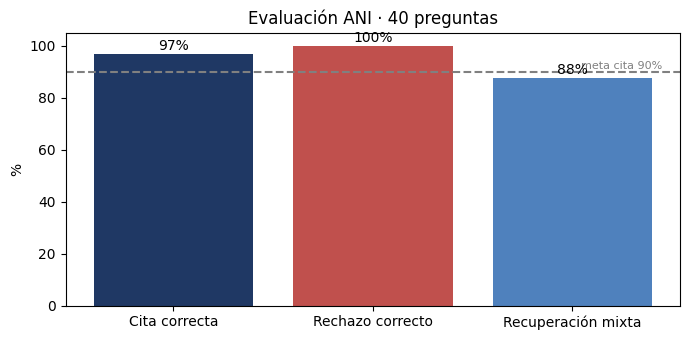


Fallos para revisar:
  #37 [cita, mixta, art. inventado 39] Si el reglamento del liceo dice algo distinto al decreto del ministerio, ¿cuál vale?

Guardado en Drive: ANI_resultados_evaluacion_v7.xlsx y ANI_metricas_v7.png


In [12]:
# ============================================================
# 9 · EVALUACIÓN 1/2: ANI responde las 40 preguntas del set de prueba + métricas de cita y rechazo
#   Requisito: ANI_set_preguntas_prueba.xlsx en la carpeta ANI. Gasta 1-3 consultas por pregunta.
#   Si se corta (cuota o 503), vuelve a ejecutar: retoma donde quedó (las respuestas se guardan en Drive).
#   Versiones anteriores (v1 a v6) quedaron medidas en los notebooks de iteraciones (P1–P4).
# ============================================================
class EvaluacionOmitida(Exception):
    def _render_traceback_(self):
        return ["⏭️ Evaluación omitida: ANI ya está listo en la celda 7. Para volver a medir, pon EVALUAR = True en la celda 1."]
if not EVALUAR:
    raise EvaluacionOmitida()

import glob, os, re, time, json
import pandas as pd
import matplotlib.pyplot as plt

PAUSA = 6        # segundos entre preguntas (evita el error 429 de la cuota gratuita)
VERSION = "v7"   # v6 + etiqueta de protocolo, medida con GPU (usa "v6" para ver los resultados guardados de Adolfo)
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"

# ---------- 1. Cargar preguntas ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
if not candidatos:
    raise FileNotFoundError("No encontré ANI_set_preguntas_prueba.xlsx ni en la carpeta ANI ni en la del proyecto.")
archivo = sorted(candidatos)[-1]
df = pd.read_excel(archivo, sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
print(f"{len(df)} preguntas cargadas desde {os.path.basename(archivo)}")

# ---------- 2. Funciones de evaluación ----------
def paginas(texto):
    """'19-20' -> {19, 20}; '62 / 70' -> {62, 70}; '17.0' -> {17}"""
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def fuentes(respuesta):
    """Lista de (documento | ubicación, {páginas}), separando fuentes unidas con ';'"""
    out = []
    for linea in respuesta.splitlines():
        if "Fuente" not in linea:
            continue
        doc = ""
        for parte in linea.split(";"):
            if doc_clave(parte):
                doc = parte.split(",")[0]
            m = re.findall(r"p[áa]gs?\.?\s*([\d\s,\-–y]+)", parte)
            out.append((f"{doc} | {parte}", set().union(*map(paginas, m)) if m else set()))
    return out

def doc_clave(texto):
    claves = []
    if "Evaluaci" in texto: claves.append("Evaluaci")
    if "Convivencia" in texto: claves.append("Convivencia")
    if "Decreto" in texto: claves.append("Decreto")
    return claves

def cita_correcta(respuesta, doc_esp, pag_esp):
    """El documento interno esperado aparece citado y la página calza (tolerancia ±1)."""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pags_esp = paginas(pag_esp)
    for linea, pags in fuentes(respuesta):
        if any(c in linea for c in esperado):
            if not pags_esp:
                return True
            if any(abs(p - q) <= 1 for p in pags for q in pags_esp):
                return True
    return False

RECHAZO = "no está regulado"
def rechazo(respuesta):
    return RECHAZO in respuesta.lower()

# Artículos que existen en el corpus (para detectar artículos inventados)
ARTS_CORPUS = set()
for f in fragmentos:
    for t in (f["texto"], f["ubicacion"]):
        ARTS_CORPUS.update(re.findall(r"Art[íi]culo\s+(\d+)", t))
        ARTS_CORPUS.update(re.findall(r"Art\.\s*(\d+)", t))

def articulos_inventados(respuesta):
    citados = set(re.findall(r"Art(?:[íi]culo|\.)\s*(\d+)", respuesta))
    return sorted(citados - ARTS_CORPUS, key=int)

# ---------- 3. Correr las preguntas (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json")
resultados = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}

fallos_seguidos = 0
for _, fila in df.iterrows():
    clave = str(int(fila["n"]))
    if clave in resultados and resultados[clave]["modelo"]:
        continue
    if fallos_seguidos >= 3:
        print("⛔ 3 fallos seguidos: se acabó la cuota. Vuelve a ejecutar más tarde (retoma desde aquí).")
        break
    agente_eval = AgenteANI()                     # memoria limpia para cada pregunta
    inicio = time.time()
    texto, modelo = agente_eval.preguntar(fila["pregunta"])
    herramientas = [t["herramienta"] for t in traza]
    resultados[clave] = {"respuesta": texto, "modelo": modelo,
                         "segundos": round(time.time() - inicio, 1),
                         "herramientas": herramientas,
                         "consultas": [{"herramienta": t["herramienta"], "consulta": t["consulta"],
                                        "dominio": t.get("dominio")} for t in traza if "consulta" in t]}
    json.dump(resultados, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{clave:>2}/{len(df)}] {resultados[clave]['segundos']:>5}s · {', '.join(herramientas) or 'sin herramientas'}")
    fallos_seguidos = 0 if modelo else fallos_seguidos + 1
    time.sleep(PAUSA)

# ---------- 4. Calcular métricas ----------
pendientes = [str(int(n)) for n in df["n"] if not resultados.get(str(int(n)), {}).get("modelo")]
if pendientes:
    raise RuntimeError(f"Faltan {len(pendientes)} preguntas ({', '.join(pendientes)}). "
                       "Vuelve a ejecutar esta celda cuando se recupere la cuota.")
filas = []
for _, fila in df.iterrows():
    r = resultados[str(int(fila["n"]))]
    resp = r["respuesta"]
    debe_rechazar = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    es_mixta = str(fila["mixta"]).strip().lower() in ("sí", "si")
    rechazo_ok = rechazo(resp) if debe_rechazar else not rechazo(resp)
    cita_ok = None if debe_rechazar else cita_correcta(resp, fila["doc_esperado"], fila["pagina"])
    mixta_ok = None
    if es_mixta:
        cito = " ".join(l for l, _ in fuentes(resp))
        mixta_ok = ("buscar_norma_interna" in r["herramientas"] and "buscar_norma_externa" in r["herramientas"]
                    and "Decreto" in cito and ("Evaluaci" in cito or "Convivencia" in cito))
    filas.append({**fila.to_dict(), "respuesta_ANI": resp, "modelo": r["modelo"], "segundos": r["segundos"],
                  "herramientas": ", ".join(r["herramientas"]), "cita_correcta": cita_ok,
                  "rechazo_correcto": rechazo_ok, "mixta_recuperada": mixta_ok,
                  "articulos_inventados": ", ".join(articulos_inventados(resp)),
                  "¿Contenido correcto? (manual)": ""})
res = pd.DataFrame(filas)

normales = res[res["cita_correcta"].notna()]
rech = res[res["rechazar"].astype(str).str.lower().isin(["sí", "si"])]
mixtas = res[res["mixta_recuperada"].notna()]
falsos_rechazos = (~res.loc[~res.index.isin(rech.index), "rechazo_correcto"].astype(bool)).sum()
n_inventados = sum(len(a.split(", ")) for a in res["articulos_inventados"] if a)

metricas = pd.DataFrame([
    ["Cita correcta", normales["cita_correcta"].astype(bool).mean() * 100, "≥ 90%", f"{normales['cita_correcta'].astype(bool).sum()}/{len(normales)}"],
    ["Rechazo correcto", rech["rechazo_correcto"].astype(bool).mean() * 100, "100%", f"{rech['rechazo_correcto'].astype(bool).sum()}/{len(rech)}"],
    ["Recuperación mixta", mixtas["mixta_recuperada"].astype(bool).mean() * 100, "—", f"{mixtas['mixta_recuperada'].astype(bool).sum()}/{len(mixtas)}"],
    ["Artículos inventados", n_inventados, "0", "artículos"],
    ["Falsos rechazos", falsos_rechazos, "0", "preguntas"],
    ["Tiempo promedio (s)", res["segundos"].mean(), "—", "segundos"],
], columns=["Métrica", "Valor", "Meta", "Detalle"])
metricas["Valor"] = metricas["Valor"].round(1)
print("\n", metricas.to_string(index=False))

# ---------- 5. Guardar Excel + gráfico para el informe ----------
xlsx = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
nombres = ["Cita correcta", "Rechazo correcto", "Recuperación mixta"]
valores = metricas.set_index("Métrica").loc[nombres, "Valor"]
barras = ax.bar(nombres, valores, color=["#1F3864", "#C0504D", "#4F81BD"])
ax.axhline(90, ls="--", color="gray"); ax.text(2.45, 91, "meta cita 90%", ha="right", fontsize=8, color="gray")
ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(f"Evaluación ANI · {len(res)} preguntas")
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.savefig(os.path.join(CARPETA, f"ANI_metricas{SUFIJO}.png"), dpi=200); plt.show()

print("\nFallos para revisar:")
for _, f in res.iterrows():
    problemas = []
    if f["cita_correcta"] is not None and pd.notna(f["cita_correcta"]) and not f["cita_correcta"]: problemas.append("cita")
    if not f["rechazo_correcto"]: problemas.append("rechazo")
    if f["mixta_recuperada"] is not None and pd.notna(f["mixta_recuperada"]) and not f["mixta_recuperada"]: problemas.append("mixta")
    if f["articulos_inventados"]: problemas.append(f"art. inventado {f['articulos_inventados']}")
    if problemas:
        print(f"  #{int(f['n'])} [{', '.join(problemas)}] {f['pregunta']}")
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_metricas{SUFIJO}.png")

40 preguntas · respuestas de ANI versión v7


[ 1/40] CORRECTO   fid  8 · rel 10 · gemini-flash-latest
[ 2/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[ 3/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[ 4/40] CORRECTO   fid  8 · rel 10 · gemini-3.5-flash
[ 5/40] CORRECTO   fid 10 · rel 10 · gemini-flash-latest
[ 6/40] CORRECTO   fid 10 · rel 10 · gemini-flash-latest
[ 7/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[ 8/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[ 9/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[10/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[11/40] PARCIAL    fid 10 · rel 10 · gemini-3.5-flash
[12/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[13/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[14/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[15/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[16/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[17/40] INCORRECTO fid 10 · rel  8 · gemini-3.1-flash-lite
[18/40] CORRECTO   fid 10 · rel 10 · gemini

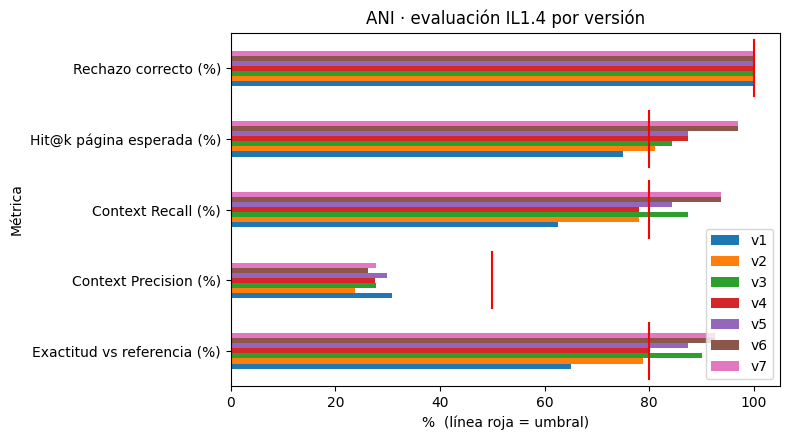


Guardado en Drive: ANI_evaluacion_IL14_v7.xlsx y ANI_evaluacion_IL14.png


In [13]:
# ============================================================
# 10 · EVALUACIÓN 2/2: juez LLM con los criterios de RA1 · IL1.4 + comparación entre versiones
#   Recuperación: Context Precision, Context Recall, Hit@k · Generación: fidelidad, relevancia, exactitud
#   El juez es un LLM a temperatura 0 que compara con la respuesta de referencia. Gasta 1 consulta por pregunta.
# ============================================================
class EvaluacionOmitida(Exception):
    def _render_traceback_(self):
        return ["⏭️ Evaluación omitida: ANI ya está listo en la celda 7. Para volver a medir, pon EVALUAR = True en la celda 1."]
if not EVALUAR:
    raise EvaluacionOmitida()

import os, re, json, time, glob
import pandas as pd
import matplotlib.pyplot as plt

VERSION = "v7"                              # misma versión de la celda anterior
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"
JUECES = ["gemini-flash-latest", "gemini-3.5-flash", "gemini-3.1-flash-lite"]  # distinto al que responde, si hay cuota
PAUSA = 4
MAX_CHARS = 4000                              # por fragmento, para no reventar el contexto del juez

# Umbrales para decir "funciona" (definidos por el equipo; el curso no fija valores)
UMBRALES = {
    "Exactitud vs referencia (%)": 80,
    "Fidelidad promedio (/10)": 8,
    "Relevancia promedio (/10)": 8,
    "Context Precision (%)": 50,
    "Context Recall (%)": 80,
    "Hit@k página esperada (%)": 80,
    "Rechazo correcto (%)": 100,
}

# ---------- 1. Cargar preguntas y respuestas del Paso 19 ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
df = pd.read_excel(sorted(candidatos)[-1], sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
resp = json.load(open(os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json"), encoding="utf-8"))
print(f"{len(df)} preguntas · respuestas de ANI versión {VERSION}")

def paginas(texto):
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def doc_clave(texto):
    return [c for c in ("Evaluaci", "Convivencia", "Decreto") if c in str(texto)]

SINONIMO = {"evaluación": "evaluacion", "convivencia": "convivencia"}

# ---------- 2. Reconstruir el contexto que recuperó el agente ----------
# Los embeddings son locales (e5-small): re-buscar no gasta cuota de Gemini.
def contexto(fila, r):
    PREGUNTA_ACTUAL["texto"] = fila["pregunta"]      # el buscador también usa la pregunta original
    frs = []
    consultas = r.get("consultas")
    if consultas:                                   # consultas reales del agente
        for c in consultas:
            if c["herramienta"] == "buscar_norma_interna":
                frs += buscar(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
            elif c["herramienta"] == "buscar_norma_externa":
                frs += buscar(c["consulta"], "externa", k=3)
    else:                                           # resultados antiguos: aproxima con la pregunta
        dom = SINONIMO.get(fila["dominio"])
        if "buscar_norma_interna" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "interna", k=4, dominio=dom)
        if "buscar_norma_externa" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "externa", k=3)
    PREGUNTA_ACTUAL["texto"] = ""
    vistos, unicos = set(), []
    for f in frs:
        clave = (f["documento"], f["ubicacion"], f["paginas"], f["texto"][:50])
        if clave not in vistos:
            vistos.add(clave); unicos.append(f)
    return unicos

def hit_pagina(frs, doc_esp, pag_esp):
    """¿Algún fragmento recuperado es del documento esperado y cubre la página (±1)?"""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pe = paginas(pag_esp)
    for f in frs:
        if any(c in f["documento"] for c in esperado):
            if not pe or any(abs(p - q) <= 1 for p in paginas(f["paginas"]) for q in pe):
                return True
    return False

# ---------- 3. El juez ----------
PROMPT_JUEZ = """Eres un evaluador estricto de un sistema RAG que responde dudas de apoderados sobre reglamentos escolares.

PREGUNTA: {pregunta}

RESPUESTA DE REFERENCIA (correcta): {referencia}

FRAGMENTOS RECUPERADOS:
{fragmentos}

RESPUESTA DEL SISTEMA:
{respuesta}

Evalúa y responde SOLO con un JSON con estas claves:
- "fidelidad": entero 1-10. ¿Todo lo que afirma la respuesta está respaldado por los FRAGMENTOS? (1-3 inventa o contradice, 4-6 parcialmente, 7-10 totalmente). Si la respuesta solo dice que no está regulado, evalúa si eso es coherente con los fragmentos.
- "relevancia": entero 1-10. ¿Responde de forma directa y útil lo que preguntó el apoderado?
- "exactitud": "CORRECTO", "PARCIAL" o "INCORRECTO" comparando con la RESPUESTA DE REFERENCIA (no exijas coincidencia literal; un plazo, número o responsable distinto es INCORRECTO).
- "fragmentos_relevantes": lista con los números de los fragmentos útiles para responder (ej: [1, 3]); [] si ninguno.
- "contexto_suficiente": true si los fragmentos contienen la información de la referencia, false si no.
- "comentario": una frase con el problema principal, o "" si no hay."""

def juzgar(fila, r, frs):
    fragmentos = "\n\n".join(f"[F{i+1}] {f['documento']} | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto'][:MAX_CHARS]}"
                             for i, f in enumerate(frs)) or "(ninguno: el agente no buscó)"
    prompt = PROMPT_JUEZ.format(pregunta=fila["pregunta"], referencia=fila["resp_esperada"],
                                fragmentos=fragmentos, respuesta=r["respuesta"])
    cfg = types.GenerateContentConfig(temperature=0, response_mime_type="application/json")
    for modelo in JUECES:
        for intento in range(3):
            try:
                out = client.models.generate_content(model=modelo, contents=prompt, config=cfg)
                datos = json.loads(re.sub(r"```json|```", "", out.text).strip())
                datos["juez"] = modelo
                return datos
            except Exception as e:
                error = str(e)
                if "PerDay" in error:
                    break
                if any(x in error for x in ("429", "503", "UNAVAILABLE")):
                    time.sleep(10 * (intento + 1)); continue
                if isinstance(e, json.JSONDecodeError):
                    continue
                raise
    return None

# ---------- 4. Correr el juez (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_juez_IL14{SUFIJO}.json")
juicios = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}
fallos = 0
for _, fila in df.iterrows():
    k = str(int(fila["n"]))
    if k in juicios:
        continue
    if fallos >= 3:
        print("⛔ El juez se quedó sin cuota. Vuelve a ejecutar más tarde (retoma desde aquí)."); break
    r = resp[k]
    frs = contexto(fila, r)
    j = juzgar(fila, r, frs)
    if j is None:
        fallos += 1; continue
    fallos = 0
    j["n_fragmentos"] = len(frs)
    j["hit_pagina"] = hit_pagina(frs, fila["doc_esperado"], fila["pagina"])
    juicios[k] = j
    json.dump(juicios, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{k:>2}/{len(df)}] {j['exactitud']:<10} fid {j['fidelidad']:>2} · rel {j['relevancia']:>2} · {j['juez']}")
    time.sleep(PAUSA)

faltan = [str(int(n)) for n in df["n"] if str(int(n)) not in juicios]
if faltan:
    raise RuntimeError(f"Faltan {len(faltan)} juicios ({', '.join(faltan)}). Vuelve a ejecutar cuando haya cuota.")

# ---------- 5. Métricas IL1.4 ----------
filas = []
for _, fila in df.iterrows():
    k = str(int(fila["n"])); j = juicios[k]; r = resp[k]
    rechazo = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    nfr = j["n_fragmentos"]
    prec = (len(set(j["fragmentos_relevantes"]) & set(range(1, nfr + 1))) / nfr) if (nfr and not rechazo) else None
    exact = {"CORRECTO": 1, "PARCIAL": 0.5, "INCORRECTO": 0}.get(str(j["exactitud"]).upper(), 0)
    # Diagnóstico IL1.4: ¿falla el recuperador o el generador?
    if exact == 1 and j["fidelidad"] >= 7:
        diag = "OK"
    elif rechazo:
        diag = "rechazo mal resuelto"
    elif not j["contexto_suficiente"]:
        diag = "falla de RECUPERACIÓN (el dato no llegó)"
    elif j["fidelidad"] < 7:
        diag = "falla de GENERACIÓN (alucina)"
    else:
        diag = "falla de GENERACIÓN (tenía el dato y no lo usó)"
    filas.append({"n": int(fila["n"]), "pregunta": fila["pregunta"], "capacidad": fila["capacidad"],
                  "respuesta_esperada": fila["resp_esperada"], "respuesta_ANI": r["respuesta"],
                  "exactitud": j["exactitud"], "exactitud_num": exact, "fidelidad": j["fidelidad"],
                  "relevancia": j["relevancia"], "context_precision": prec,
                  "context_recall": None if rechazo else bool(j["contexto_suficiente"]),
                  "hit_pagina": None if rechazo else bool(j["hit_pagina"]),
                  "rechazo_ok": ("no está regulado" in r["respuesta"].lower()) if rechazo else None,
                  "segundos": r["segundos"], "diagnostico": diag, "comentario_juez": j.get("comentario", ""),
                  "juez": j["juez"]})
res = pd.DataFrame(filas)
nr = res[res["context_recall"].notna()]

valores = {
    "Exactitud vs referencia (%)": res["exactitud_num"].mean() * 100,
    "Fidelidad promedio (/10)": res["fidelidad"].mean(),
    "Relevancia promedio (/10)": res["relevancia"].mean(),
    "Context Precision (%)": nr["context_precision"].astype(float).mean() * 100,
    "Context Recall (%)": nr["context_recall"].astype(bool).mean() * 100,
    "Hit@k página esperada (%)": nr["hit_pagina"].astype(bool).mean() * 100,
    "Rechazo correcto (%)": res["rechazo_ok"].dropna().astype(bool).mean() * 100,
}
metricas = pd.DataFrame([{"Métrica": m, "Valor": round(v, 1), "Umbral": UMBRALES[m],
                          "¿Cumple?": "✅" if v >= UMBRALES[m] else "❌"} for m, v in valores.items()])
metricas.loc[len(metricas)] = ["Latencia mediana (s)", round(res["segundos"].median(), 1), "—", "—"]
print(f"\n=== Evaluación IL1.4 · versión {VERSION} ===")
print(metricas.to_string(index=False))

cumple = (metricas["¿Cumple?"] == "✅").sum(); total = len(UMBRALES)
print(f"\nVeredicto: {cumple}/{total} criterios cumplidos →",
      "FUNCIONA" if cumple == total else "FUNCIONA PARCIALMENTE" if cumple >= total / 2 else "NO FUNCIONA AÚN")

print("\nDiagnóstico por componente (qué falla):")
print(res["diagnostico"].value_counts().to_string())
print("\nPreguntas con problemas:")
for _, f in res[res["diagnostico"] != "OK"].iterrows():
    print(f"  #{f['n']:>2} [{f['diagnostico']}] {f['pregunta']}\n       → {f['comentario_juez']}")
    print("       ANI dijo: " + f["respuesta_ANI"].replace("\n", " ")[:300] + "…")

# ---------- 6. Guardar + comparar versiones ----------
xlsx = os.path.join(CARPETA, f"ANI_evaluacion_IL14{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

comparacion = {}
for archivo in sorted(glob.glob(os.path.join(CARPETA, "ANI_evaluacion_IL14*.xlsx"))):
    m = re.search(r"IL14_?(v\d+)?\.xlsx$", archivo)
    ver = (m.group(1) if m and m.group(1) else "v1")
    tabla = pd.read_excel(archivo, sheet_name="Métricas").set_index("Métrica")["Valor"]
    comparacion[ver] = tabla
comp = pd.DataFrame(comparacion).loc[list(UMBRALES)]
if comp.shape[1] > 1:
    print("\nComparación entre versiones:")
    print(comp.to_string())

pct = [m for m in UMBRALES if "%" in m]
ax = comp.loc[pct].plot(kind="barh", figsize=(8, 4.5))
for i, m in enumerate(pct):
    ax.plot([UMBRALES[m]] * 2, [i - 0.4, i + 0.4], color="red", lw=1.5)
ax.set_xlim(0, 105); ax.set_xlabel("%  (línea roja = umbral)")
ax.set_title("ANI · evaluación IL1.4 por versión"); plt.tight_layout()
plt.savefig(os.path.join(CARPETA, "ANI_evaluacion_IL14.png"), dpi=200); plt.show()
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_evaluacion_IL14.png")